## 1 - Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

import yaml
cfg = yaml.safe_load(Path('../config/config.yaml').read_text())

path_data = cfg['path_data']
path_wth = cfg['path_wth']

df_gh = pd.read_csv(path_data)
df_wt = pd.read_csv(path_wth)

df_gh["ts"] = pd.to_datetime(df_gh["timestamp"], 
                             unit="ms", 
                             utc=True) # timestamp en ms
df_wt['ts'] = pd.to_datetime(df_wt['time_utc'])

# ts_ceil = datetime64[ns, UTC] (avec timezone)
# ts = datetime64[ns] (sans timezone)

print(f"Greenhouse U5: {df_gh.shape}")
print(f"Time: {df_gh['ts'].min()} à {df_gh['ts'].max()}")

print(f"Weather: {df_wt.shape}")
print(f"Time: {df_wt['ts'].min()} à {df_wt['ts'].max()}")

Greenhouse U5: (37975, 7)
Time: 2024-06-28 11:29:14+00:00 à 2026-03-17 18:10:40+00:00
Weather: (8760, 14)
Time: 2025-01-01 00:00:00 à 2025-12-31 23:00:00


#### Raw datas

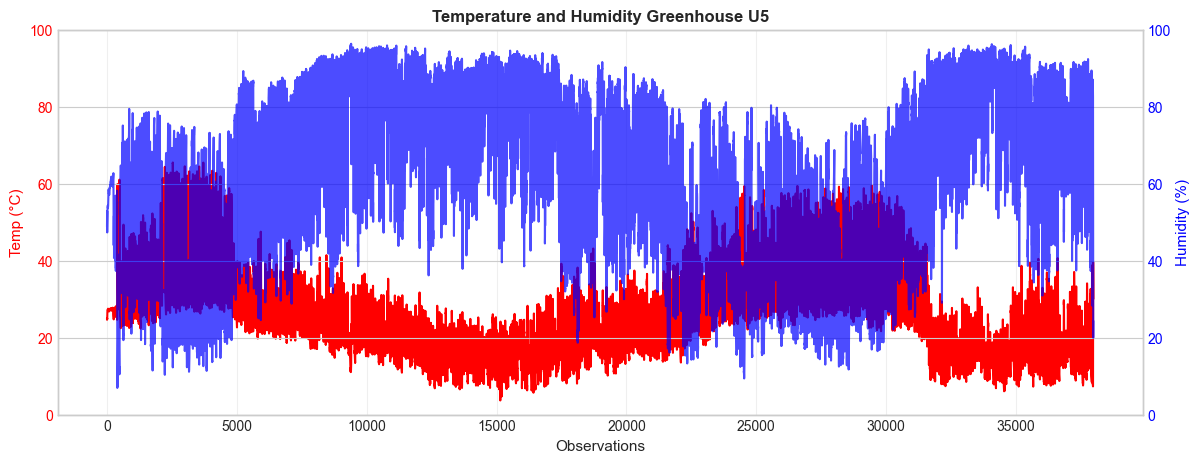

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Température (axe gauche)
ax1.plot(df_gh['tempint'], color='red', label='Temp', linewidth=1.5)
ax1.set_ylabel('Temp (°C)', fontsize=11, color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0, 100)
# Humidité (axe droit)
ax2 = ax1.twinx()
ax2.plot(df_gh['humedadint'], color='blue', label='Humidity', linewidth=1.5, alpha=0.7)
ax2.set_ylabel('Humidity (%)', fontsize=11, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 100)

ax1.set_xlabel('Observations', fontsize=11)
plt.title('Temperature and Humidity Greenhouse U5', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.show()

In [6]:
print("=" * 50)
print("GH U5")
print("=" * 50)
print(df_gh.head(2))
print("\nInfo:")
print(df_gh.info())
print("\nStatistiques:")
print(df_gh.describe())

GH U5
       timestamp          fecha      hora  tempint  humedadint  dispositivo  \
0  1719574154000  1719532800000  11:29:00    25.01        48.8         1055   
1  1719575126000  1719532800000  11:45:00    24.76        50.3         1055   

                         ts  
0 2024-06-28 11:29:14+00:00  
1 2024-06-28 11:45:26+00:00  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37975 entries, 0 to 37974
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   timestamp    37975 non-null  int64              
 1   fecha        37975 non-null  int64              
 2   hora         37975 non-null  object             
 3   tempint      37975 non-null  float64            
 4   humedadint   37975 non-null  float64            
 5   dispositivo  37975 non-null  int64              
 6   ts           37975 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(2), int64(3), object(1)
m

In [7]:
print("\n" + "=" * 50)
print("WEATHER")
print("=" * 50)
print(df_wt.head(5))
print("\nColonnes disponibles:")
print(df_wt.columns.tolist())
print("\nStatistiques:")
print(df_wt.describe())


WEATHER
           time_utc  cloud_cover  dew_point_2m  precipitation  pressure_msl  \
0  2025-01-01T00:00           14           6.0            0.0        1029.3   
1  2025-01-01T01:00           11           6.3            0.0        1028.6   
2  2025-01-01T02:00           32           5.9            0.0        1028.8   
3  2025-01-01T03:00           32           5.8            0.0        1028.6   
4  2025-01-01T04:00           17           5.6            0.0        1028.2   

   rain  relative_humidity_2m  shortwave_radiation  snowfall  temperature_2m  \
0   0.0                    75                  0.0       0.0            10.2   
1   0.0                    80                  0.0       0.0             9.7   
2   0.0                    81                  0.0       0.0             9.1   
3   0.0                    80                  0.0       0.0             9.1   
4   0.0                    82                  0.0       0.0             8.4   

   wind_direction_10m  wind_gusts_1

#### Step time

The data is irregularly spaced, with gaps ranging from a few seconds to over a month. 0 days 00:01:46 = 2 points in less than 2 minutes, 37 days 11:06:47 = a gap of one month

In [8]:
# step time = diff
diff = df_gh['ts'].diff()
diff.value_counts().sort_index()

ts
0 days 00:01:46     1
0 days 00:02:22     1
0 days 00:02:47     1
0 days 00:03:49     1
0 days 00:04:10     1
                   ..
4 days 13:25:58     1
4 days 19:01:01     1
5 days 04:54:54     1
6 days 21:56:48     1
37 days 11:06:47    1
Name: count, Length: 1444, dtype: int64

In [9]:
# round
df_gh['ts_ceil'] = df_gh['ts'].dt.round('1h')
df_gh['ts_ceil'].diff().value_counts().head(8)

# 0 days 00:00:00     25996 = duplicate same h
# 0 days 01:00:00     11671 = [] = 1h normal
# 0 days 03:00:00        51 = gap of 2h

ts_ceil
0 days 00:00:00    25996
0 days 01:00:00    11671
0 days 02:00:00      155
0 days 03:00:00       51
0 days 04:00:00       18
0 days 05:00:00       14
0 days 08:00:00        8
1 days 01:00:00        5
Name: count, dtype: int64

In [10]:
df_gh['ts_ceil'].value_counts()
# max 5 duplicates

ts_ceil
2024-07-04 07:00:00+00:00    5
2024-07-03 19:00:00+00:00    5
2024-06-28 13:00:00+00:00    4
2026-03-17 07:00:00+00:00    4
2026-03-16 15:00:00+00:00    4
                            ..
2026-03-15 12:00:00+00:00    1
2026-03-15 08:00:00+00:00    1
2025-02-05 19:00:00+00:00    1
2025-02-05 03:00:00+00:00    1
2025-09-11 23:00:00+00:00    1
Name: count, Length: 11979, dtype: int64

In [11]:
# mean /h
df_gh = df_gh.groupby('ts_ceil').agg({
    'tempint': 'mean',
    'humedadint': 'mean'
}).reset_index()

#### NaN values

In [12]:
# Create a complete time series
date_range = pd.date_range(df_gh['ts_ceil'].min(), 
                           df_gh['ts_ceil'].max(), 
                           freq='1h')
df_gh = df_gh.set_index('ts_ceil').reindex(date_range).reset_index()
df_gh.rename(columns={'index': 'ts_ceil'}, inplace=True)
df_gh

,ts_ceil,tempint,humedadint
0,2024-06-28 11:00:00+00:00,25.010000,48.800000
1,2024-06-28 12:00:00+00:00,24.706667,50.850000
2,2024-06-28 13:00:00+00:00,24.930000,51.970000
3,2024-06-28 14:00:00+00:00,25.290000,48.242500
4,2024-06-28 15:00:00+00:00,26.386667,50.543333
...,...,...,...
15051,2026-03-17 14:00:00+00:00,NaN,NaN
15052,2026-03-17 15:00:00+00:00,39.600000,23.420000
15053,2026-03-17 16:00:00+00:00,38.765000,23.695000
15054,2026-03-17 17:00:00+00:00,36.756667,21.523333


In [13]:
# Nb NaN
val = df_gh.isnull().sum()
pct = (df_gh.isna().sum()/df_gh.shape[0]).round(3)

print("Valeurs manquantes - Serre U5:")
print(pd.DataFrame({
    'Manquantes': val,
    'Pourcentage': pct
}))

Valeurs manquantes - Serre U5:
            Manquantes  Pourcentage
ts_ceil              0        0.000
tempint           3077        0.204
humedadint        3077        0.204


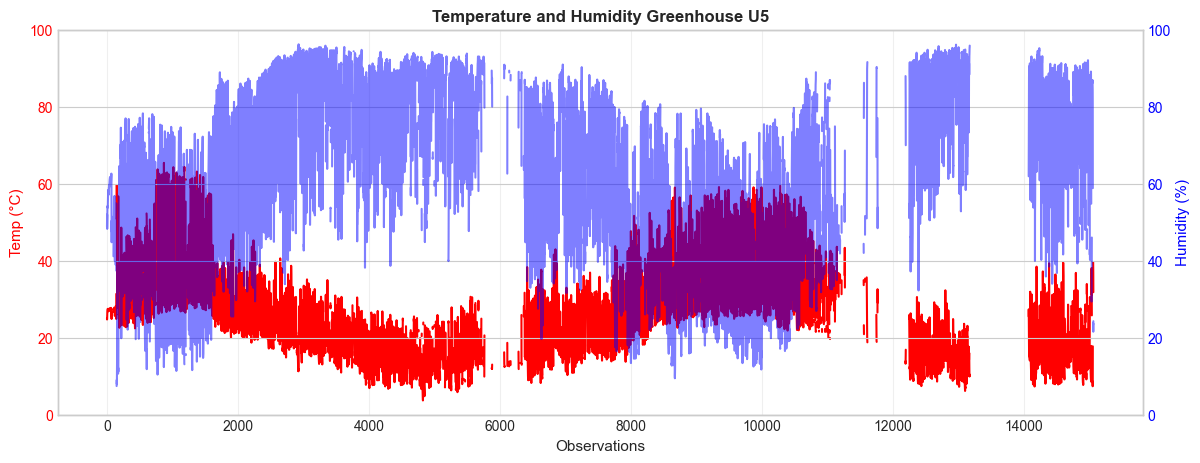

In [14]:
# Viz serie temp complte
fig, ax1 = plt.subplots(figsize=(14, 5))

# Température (axe gauche)
ax1.plot(df_gh['tempint'], color='red', label='Temp', linewidth=1.5)
ax1.set_ylabel('Temp (°C)', fontsize=11, color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0, 100) 
# Humidité (axe droit)
ax2 = ax1.twinx()
ax2.plot(df_gh['humedadint'], color='blue', label='Humidity', linewidth=1.5, alpha=0.5)
ax2.set_ylabel('Humidity (%)', fontsize=11, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 100)

ax1.set_xlabel('Observations', fontsize=11)
plt.title('Temperature and Humidity Greenhouse U5', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.show()

In [16]:
# Viz windows
nan_mask = df_gh['tempint'].isna()
df_gh['nan_group'] = (~nan_mask).cumsum()
holes_info = df_gh[nan_mask].groupby('nan_group').agg({
    'ts_ceil': ['min', 'max', 'count']
}).reset_index()

holes_info.columns = ['nan_group', 'debut', 'fin', 'nb_h_missing']
holes_info['duree'] = holes_info['fin'] - holes_info['debut']

holes_info[holes_info['nb_h_missing'] > 5].sort_values('nb_h_missing', ascending=False).head(10)

,nan_group,debut,fin,nb_h_missing,duree
287,11033,2025-12-29 04:00:00+00:00,2026-02-04 14:00:00+00:00,899,37 days 10:00:00
277,10104,2025-11-05 17:00:00+00:00,2025-11-12 13:00:00+00:00,165,6 days 20:00:00
263,10068,2025-10-17 12:00:00+00:00,2025-10-22 15:00:00+00:00,124,5 days 03:00:00
279,10106,2025-11-13 13:00:00+00:00,2025-11-18 06:00:00+00:00,114,4 days 17:00:00
146,5388,2025-02-23 13:00:00+00:00,2025-02-28 00:00:00+00:00,108,4 days 11:00:00
275,10102,2025-10-31 17:00:00+00:00,2025-11-04 15:00:00+00:00,95,3 days 22:00:00
262,10067,2025-10-14 16:00:00+00:00,2025-10-17 10:00:00+00:00,67,2 days 18:00:00
149,5398,2025-03-01 11:00:00+00:00,2025-03-04 02:00:00+00:00,64,2 days 15:00:00
152,5401,2025-03-05 12:00:00+00:00,2025-03-08 00:00:00+00:00,61,2 days 12:00:00
164,5424,2025-03-14 23:00:00+00:00,2025-03-17 03:00:00+00:00,53,2 days 04:00:00


In [18]:
# Valeurs manquantes Météo
missing_meteo = df_wt.isnull().sum()
missing_pct_meteo = (missing_meteo / len(df_wt) * 100).round(2)

print("NaN values weather: ")
print(pd.DataFrame({
    'Nb': missing_meteo,
    '%': missing_pct_meteo
}))

NaN values weather: 
                      Nb    %
time_utc               0  0.0
cloud_cover            0  0.0
dew_point_2m           0  0.0
precipitation          0  0.0
pressure_msl           0  0.0
rain                   0  0.0
relative_humidity_2m   0  0.0
shortwave_radiation    0  0.0
snowfall               0  0.0
temperature_2m         0  0.0
wind_direction_10m     0  0.0
wind_gusts_10m         0  0.0
wind_speed_10m         0  0.0
ts                     0  0.0


## 4. Visualisation des séries temporelles

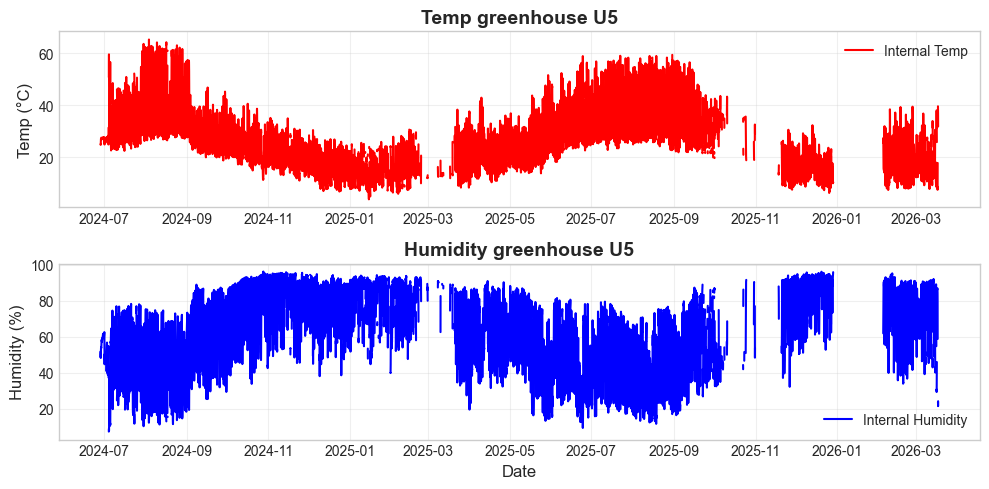

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

if 'tempint' in df_gh.columns:
    axes[0].plot(df_gh['ts_ceil'], df_gh['tempint'], 
                 label='Internal Temp', color='red', linewidth=1.5)
    axes[0].set_ylabel('Temp (°C)', fontsize=12)
    axes[0].set_title('Temp greenhouse U5', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if 'humedadint' in df_gh.columns:
    axes[1].plot(df_gh['ts_ceil'], df_gh['humedadint'], 
                 label='Internal Humidity', color='blue', linewidth=1.5)
    axes[1].set_ylabel('Humidity (%)', fontsize=12)
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_title('Humidity greenhouse U5', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
 df_wt.columns

Index(['time_utc', 'cloud_cover', 'dew_point_2m', 'precipitation',
       'pressure_msl', 'rain', 'relative_humidity_2m', 'shortwave_radiation',
       'snowfall', 'temperature_2m', 'wind_direction_10m', 'wind_gusts_10m',
       'wind_speed_10m', 'ts'],
      dtype='object')

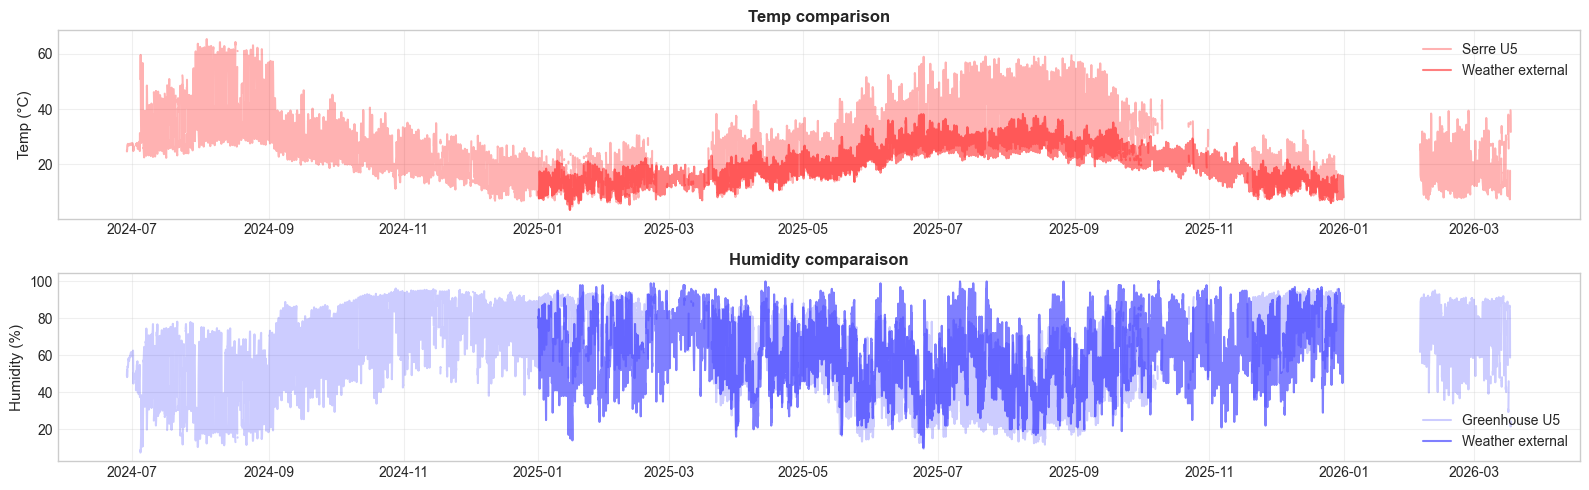

In [29]:
# Comparison Greenhouse vs weather
fig, axes = plt.subplots(2, 1, figsize=(16, 5))

# Température
if 'tempint' in df_gh.columns:
    temp_col = [c for c in df_wt.columns if 'temperature' in c.lower()]
    if temp_col:
        axes[0].plot(df_gh['ts_ceil'], df_gh['tempint'], 
                     color='red', label='Serre U5', alpha=0.3, linewidth=1.5)
        axes[0].plot(df_wt['ts'], df_wt[temp_col[0]],
                     color='red', label='Weather external', alpha=0.5, linewidth=1.5)
        axes[0].set_title('Temp comparison', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Temp (°C)', fontsize=11)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

# Humidité
if 'humedadint' in df_gh.columns:
    humidity_col = [c for c in df_wt.columns if 'humidity' in c.lower()]
    if humidity_col:
        axes[1].plot(df_gh['ts_ceil'], df_gh['humedadint'], 
                     color='blue', label='Greenhouse U5', alpha=0.2, linewidth=1.5)
        axes[1].plot(df_wt['ts'], df_wt[humidity_col[0]], 
                     color='blue', label='Weather external', alpha=0.5, linewidth=1.5)
        axes[1].set_title('Humidity comparaison', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Humidity (%)', fontsize=11)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Distribution

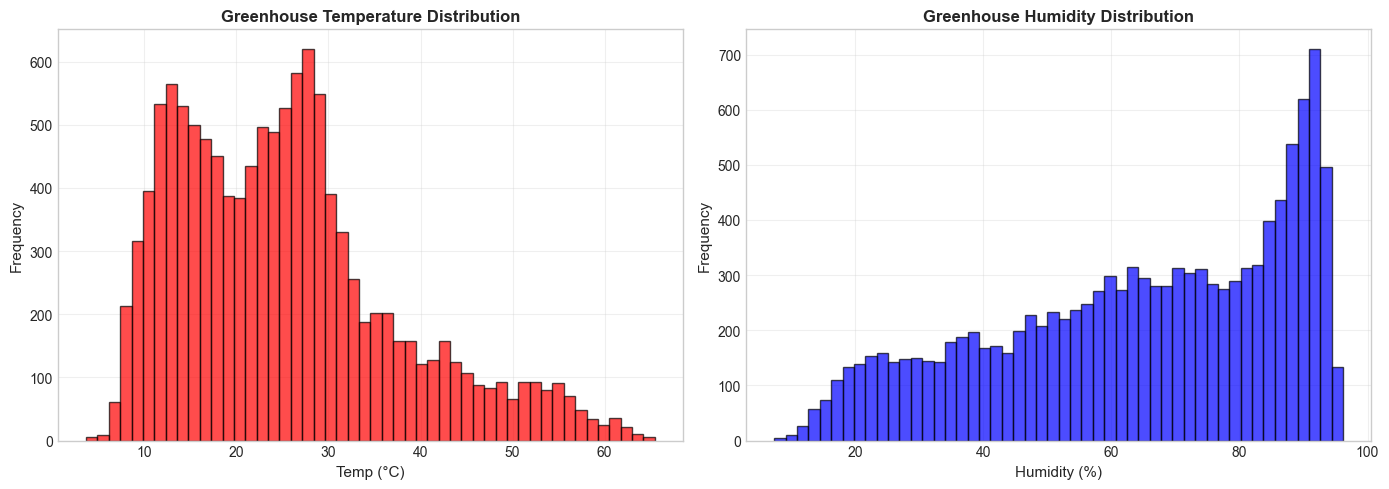

In [30]:
# Distribution des variables serre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'tempint' in df_gh.columns:
    axes[0].hist(df_gh['tempint'].dropna(), bins=50, alpha=0.7, color='red', edgecolor='black')
    axes[0].set_xlabel('Temp (°C)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Greenhouse Temperature Distribution', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

if 'humedadint' in df_gh.columns:
    axes[1].hist(df_gh['humedadint'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[1].set_xlabel('Humidity (%)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Greenhouse Humidity Distribution', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# df_wt

#### Correlations

In [38]:
# Fusion des données serre et météo
# Supprimer la timezone de ts_ceil pour la rendre compatible
df_gh_merge = df_gh[['ts_ceil', 'tempint', 'humedadint']].copy()
df_gh_merge['ts_ceil'] = df_gh_merge['ts_ceil'].dt.tz_localize(None)

df_wt_merge = df_wt.copy()
df_wt_merge['ts'] = df_wt_merge['ts'].dt.tz_localize(None)

# Fusion
df_merged = pd.merge_asof(df_gh_merge.sort_values('ts_ceil'), 
                            df_wt_merge.sort_values('ts'),
                            left_on='ts_ceil',
                            right_on='ts',
                            direction='nearest',
                            tolerance=pd.Timedelta('1h'))

# Garder que les lignes sans NaN dans les colonnes clés
df_merged = df_merged.dropna(subset=['ts_ceil', 'ts'])

print(f"Merge data: {df_merged.shape}")
print(f"Nan values after merge: {df_merged.isnull().sum().sum()}")
print(f"Time after merge: {df_merged['ts_ceil'].min()} à {df_merged['ts_ceil'].max()}")

Merged data: (8762, 17)
Nan values after merge: 4084
Time after merge: 2024-12-31 23:00:00 à 2026-01-01 00:00:00


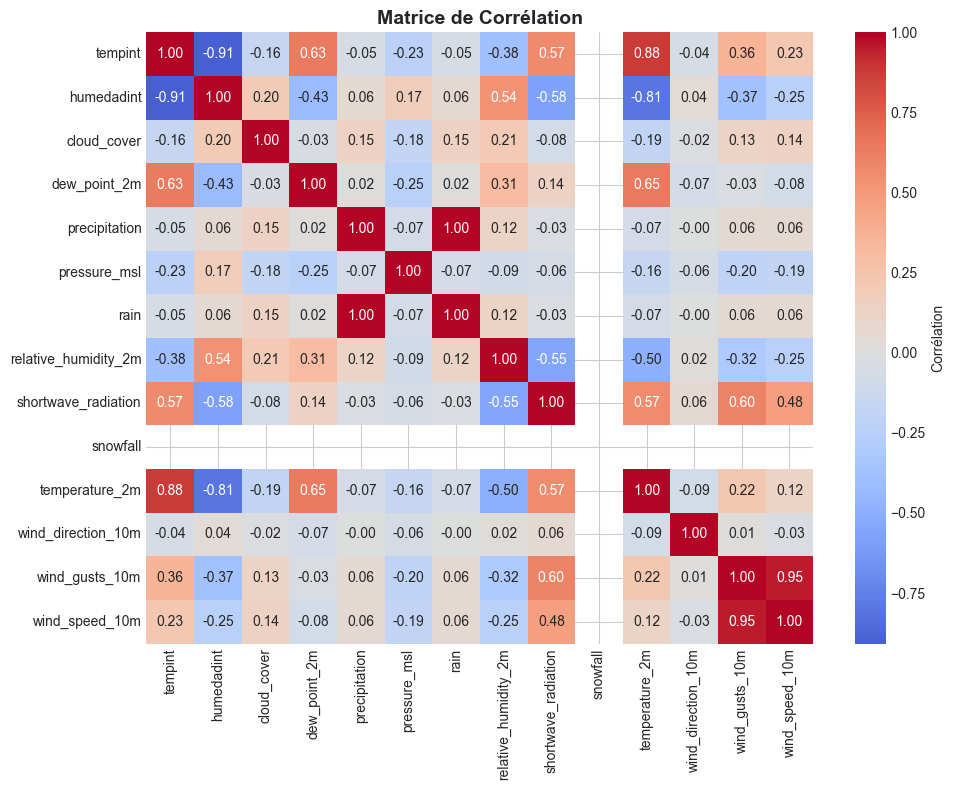

In [39]:
# Mat corr
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    corr_matrix = df_merged[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, cbar_kws={'label': 'Corrélation'})
    plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

#### Resume

In [40]:
print("=" * 60)
print("RÉSUMÉ EDA")
print("=" * 60)
print(f"\n✓ Données collectées de {df_gh['ts_ceil'].min()} à {df_gh['ts_ceil'].max()}")
print(f"✓ Nombre d'observations serre: {len(df_gh):,}")
print(f"✓ Pas de temps: irregulier -> corriger 1h (données horaires)")

if 'tempint' in df_gh.columns:
    print(f"\n📊 Température Serre U5:")
    print(f"   Min: {df_gh['tempint'].min():.2f}°C")
    print(f"   Max: {df_gh['tempint'].max():.2f}°C")
    print(f"   Moyenne: {df_gh['tempint'].mean():.2f}°C")
    print(f"   Écart-type: {df_gh['tempint'].std():.2f}°C")

if 'humedadint' in df_gh.columns:
    print(f"\n💧 Humidité Serre U5:")
    print(f"   Min: {df_gh['humedadint'].min():.2f}%")
    print(f"   Max: {df_gh['humedadint'].max():.2f}%")
    print(f"   Moyenne: {df_gh['humedadint'].mean():.2f}%")
    print(f"   Écart-type: {df_gh['humedadint'].std():.2f}%")

print("\n" + "=" * 60)

RÉSUMÉ EDA

✓ Données collectées de 2024-06-28 11:00:00+00:00 à 2026-03-17 18:00:00+00:00
✓ Nombre d'observations serre: 15,056
✓ Pas de temps: irregulier -> corriger 1h (données horaires)

📊 Température Serre U5:
   Min: 3.67°C
   Max: 65.45°C
   Moyenne: 25.34°C
   Écart-type: 12.02°C

💧 Humidité Serre U5:
   Min: 7.41%
   Max: 96.18%
   Moyenne: 64.39%
   Écart-type: 22.76%



#### CLS

Greenhouse datas : <br>
. irregularity of step time <br>
. round up to the nearest hour + mean values /h <br>
. Nan (20%), range = 1d to 37d <br>

Weather datas & sensor : <br>
. no Nan <br>
. select sensor near of the weather data
